# Brazil-Real-Estate-EDA

## Project Objectives:
To answer the question **Are property prices in Mexico more influenced by property size or by location?**

## Technical stack:
* **Data Manipulation:** `NumPy`, `Pandas`\
* **Data Visulaizatio:** `Matplotlib`, `Seaborn`


## Getting to know the data

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
# Define the path to the first file
path_1 = "./Data/brasil-real-estate-1.csv"

# Load the dataset
df1 = pd.read_csv(path_1)

### Inspecting the data: Five-Method Ritual

In [3]:
# Get the head of the dataframe
df1.head(10)

,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"
5,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.614414,-35.735621",56.0,"$75,727.07"
6,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.584755,-35.662909",68.0,"$110,916.18"
7,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.658285,-35.703827",187.0,"$249,641.14"
8,apartment,|Brasil|Alagoas|Maceió|,Northeast,NaN,65.0,"$100,792.61"
9,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.66082,-35.702976",90.0,"$115,459.02"


**Observations:**
* "place_with_parent_names" has more than one info. 
* lat-lon combines two columns.
* price_usd has $ symbol in the entries.

In [4]:
# Get the shape of the dataframe
df1.shape

(12834, 6)

In [5]:
# Get the info
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  str    
 1   place_with_parent_names  12834 non-null  str    
 2   region                   12834 non-null  str    
 3   lat-lon                  11551 non-null  str    
 4   area_m2                  12834 non-null  float64
 5   price_usd                12834 non-null  str    
dtypes: float64(1), str(5)
memory usage: 601.7 KB


**Observations:**
* lat-lon is str.
* price_usd is str.

In [6]:
# Reveal the types 
df1.dtypes

property_type                  str
place_with_parent_names        str
region                         str
lat-lon                        str
area_m2                    float64
price_usd                      str
dtype: object

In [7]:
# Missing entries
df1.isnull().sum()

property_type                 0
place_with_parent_names       0
region                        0
lat-lon                    1283
area_m2                       0
price_usd                     0
dtype: int64

**Observations:**
- lat-lon is missing 1283 entries.

Before doing anything with the missing entries, let's explore whether they are clustered or not.

<Axes: >

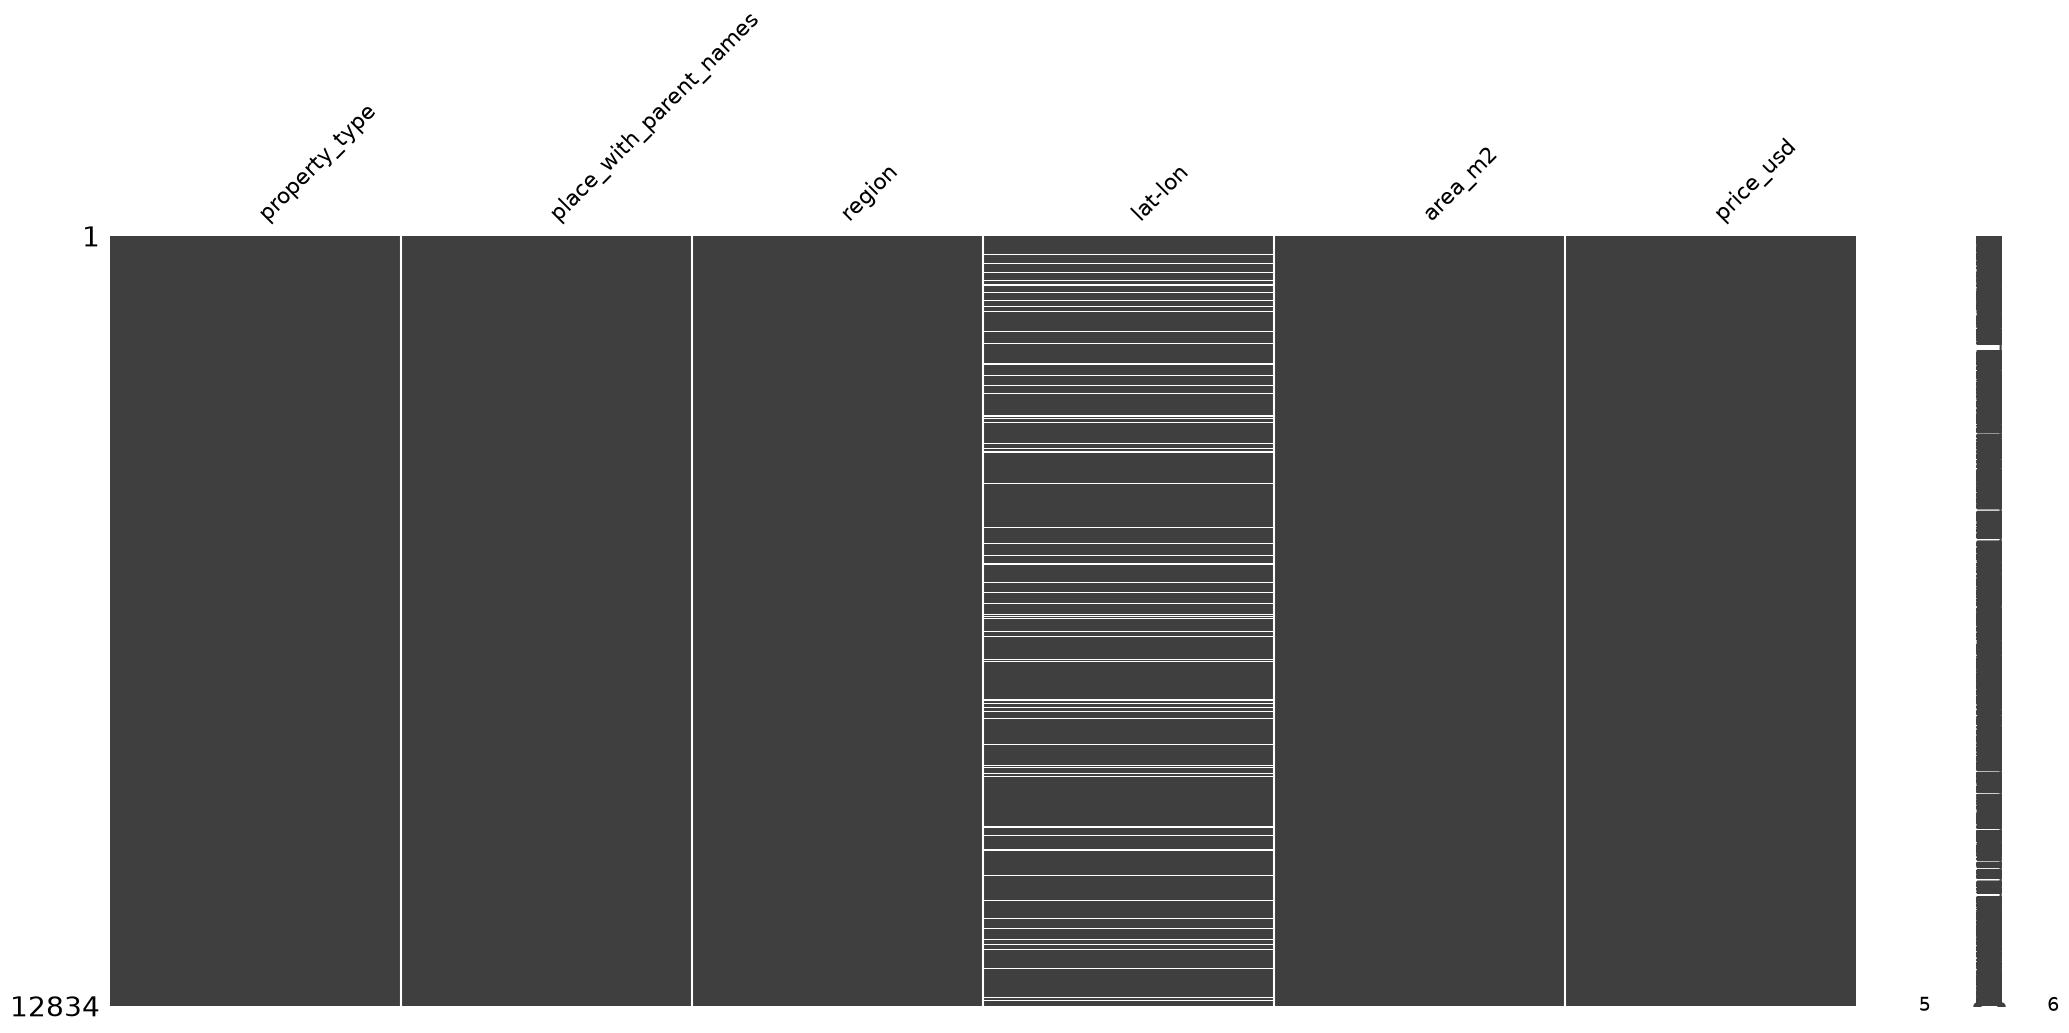

In [8]:
# Draw a matrix plot to visualize cluster
msno.matrix(df1)

**Observations:** 
* Nope, they aren't clustered.

In [9]:
# Calculate the percentag of missing entries
pct_missing_entries = (df1.isnull().sum().sum() / len(df1)) * 100
print(f"Percentage of missing entries: {pct_missing_entries:.2f}%")

Percentage of missing entries: 10.00%


Since, missing entries are just 10%, it is perfectly ok remove the observations containing those missing values. 

In [10]:
df1_clean = (
    # Copy the dataframe
    df1.copy()      # saves time
    # Drop the missing rows
    .dropna(ignore_index=True)              # ignore_index=True resets the indexes

    # Modify "price_usd" and create "lon", "lat", "state" variables
    .assign(
        # Modify "price_usd" variable
        price_usd = lambda x: x["price_usd"]
                                .str.replace("$", "",  regex=False)       # .str was used because x["price_usd"] is a pandas series rather than a single text
                                .str.replace(",", "", regex=False)
                                .astype(float),
        # Create "lat" and split "lat-lon"
        lat = lambda x: x["lat-lon"]
                        .str.split(",", expand=True)[0]
                        .astype(float),

        # Create "lon" and split "lat-lon"
        lon = lambda x: x["lat-lon"]
                        .str.split(",", expand=True)[1]
                        .astype(float),
        # Create "state" variable
        state = lambda x: x["place_with_parent_names"]
                        .str.split("|", expand=True)[2]
                        .astype(str)
    )
    # Drop the unnecessary variables
    .drop(columns=["place_with_parent_names", "lat-lon"])
)


In [11]:
# Check the dataframe with head
df1_clean.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


In [12]:
# Check the dataframe with info
df1_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 11551 entries, 0 to 11550
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11551 non-null  str    
 1   region         11551 non-null  str    
 2   area_m2        11551 non-null  float64
 3   price_usd      11551 non-null  float64
 4   lat            11551 non-null  float64
 5   lon            11551 non-null  float64
 6   state          11551 non-null  str    
dtypes: float64(4), str(3)
memory usage: 631.8 KB


In [13]:
# Define the path for 2nd dataframe
path_2 = "./Data/brasil-real-estate-2.csv"

# Read the csv file
df2 = pd.read_csv(path_2)

# Inspecting the 2nd dataframe with head
df2.head()

,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36


**Observations:** 
* Price is in brl instead of usd.

In [14]:
# Inspect the 2nd dataframe with shape
df2.shape

(12833, 7)

In [15]:
# Inspect the 2nd dataframe with info
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  12833 non-null  str    
 1   state          12833 non-null  str    
 2   region         12833 non-null  str    
 3   lat            12833 non-null  float64
 4   lon            12833 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      12833 non-null  float64
dtypes: float64(4), str(3)
memory usage: 701.9 KB


In [16]:
# Inspect the 2nd datafrme with isnull()
df2.isnull().sum()

property_type       0
state               0
region              0
lat                 0
lon                 0
area_m2          1540
price_brl           0
dtype: int64

In [17]:
# Calculate the percentage of missing entries
pct_missing_entries_2 = (df2.isnull().sum().sum() / len(df2)) * 100
print(f"Percentage of missing entries in the second dataframe: {pct_missing_entries_2:.2f}%")

Percentage of missing entries in the second dataframe: 12.00%


### Since this value is about 12%, we can simply remove those rows containing the missing values.

In [18]:
# Define the brl to usd rate
brl_to_usd_rate = 0.19

df2_clean = (
                # Copy the 2nd dataframe
                df2.copy()

                # Create the price_usd variable from price_brl
                .assign(
                    price_usd = lambda x: x["price_brl"] * brl_to_usd_rate
                )
                # Drop the price_brl column
                .drop(columns=["price_brl"])

                # Remove the rows containing NaN 
                .dropna()
)

In [19]:
# Inspect the 2nd dataframe with head
df2_clean.head()

,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,78702.3662
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,161197.6207
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,56893.2732
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,161197.6207
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,88184.5784


In [20]:
# Inspect the 2nd dataframe with info
df2_clean.info()

<class 'pandas.DataFrame'>
Index: 11293 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11293 non-null  str    
 1   state          11293 non-null  str    
 2   region         11293 non-null  str    
 3   lat            11293 non-null  float64
 4   lon            11293 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_usd      11293 non-null  float64
dtypes: float64(4), str(3)
memory usage: 705.8 KB


In [21]:
# Check if all columns are identical for the dataframes
columns_match = set(df1_clean.columns) == set(df2_clean.columns)

if columns_match:
    print("Columns matched")
else:
    print("Columns didn't match")

Columns matched


In [22]:
# Concatenate the two dataframes
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# Inspect the new dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  str    
 1   region         22844 non-null  str    
 2   area_m2        22844 non-null  float64
 3   price_usd      22844 non-null  float64
 4   lat            22844 non-null  float64
 5   lon            22844 non-null  float64
 6   state          22844 non-null  str    
dtypes: float64(4), str(3)
memory usage: 1.2 MB


In [23]:
# Inspect the new dataframe with head
df.head()

,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


In [24]:
# Save the cleaned dataframe as csv
df.to_csv("./Data/brasil-read-estate-combined-clean.csv", index=False)

In [25]:
# Checking the summary statistics
df.describe().round(2)   # only for numbers; round(2) would enforce 2 digit visibility

,area_m2,price_usd,lat,lon
count,22844.00,22844.00,22844.00,22844.00
mean,115.02,154400.32,-20.40,-45.34
std,47.74,87377.55,7.68,4.84
min,53.00,45514.62,-33.69,-63.91
25%,76.00,90494.91,-25.47,-49.24
50%,103.00,130854.54,-22.93,-46.57
75%,142.00,196592.39,-15.84,-43.10
max,252.00,524246.39,0.02,-34.80


**Observations:**
* Both area_m2 and price_usd has mean > median (50%). A classic indication of right-skew.

In [26]:
# Summary statistics 
df.describe(include="str")   # for string data types

,property_type,region,state
count,22844,22844,22844
unique,2,5,25
top,apartment,Southeast,Minas Gerais
freq,18463,8533,2680


In [27]:
# Summary statistics
df.describe(include="all")  # for both strings and numbers

,property_type,region,area_m2,price_usd,lat,lon,state
count,22844,22844,22844.000000,22844.000000,22844.000000,22844.000000,22844
unique,2,5,NaN,NaN,NaN,NaN,25
top,apartment,Southeast,NaN,NaN,NaN,NaN,Minas Gerais
freq,18463,8533,NaN,NaN,NaN,NaN,2680
mean,NaN,NaN,115.020224,154400.317829,-20.398011,-45.338626,NaN
std,NaN,NaN,47.742932,87377.553136,7.676672,4.835724,NaN
min,NaN,NaN,53.000000,45514.619700,-33.692432,-63.905184,NaN
25%,NaN,NaN,76.000000,90494.910000,-25.466106,-49.236000,NaN
50%,NaN,NaN,103.000000,130854.537100,-22.933168,-46.574148,NaN
75%,NaN,NaN,142.000000,196592.390000,-15.839121,-43.099617,NaN


## Visualization

### Univariate Analysis: Understanding one variable at a time

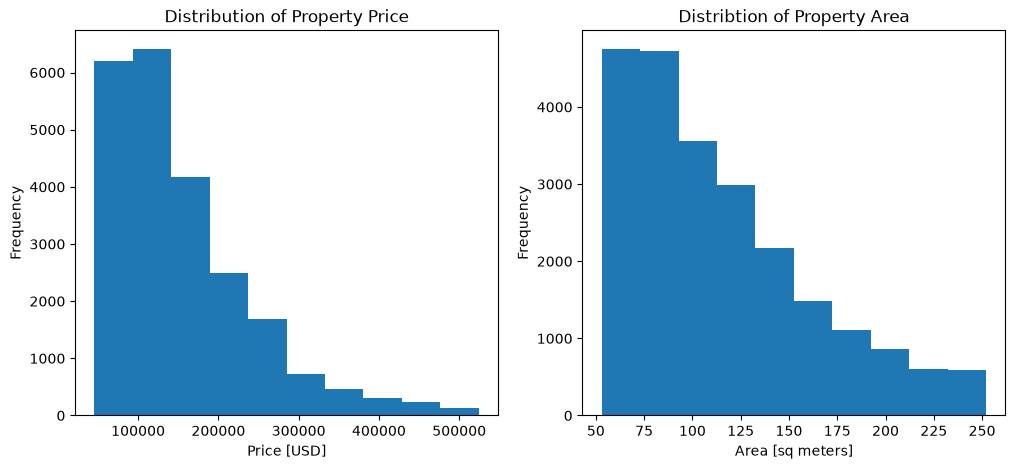

In [28]:
# Create a histogram for price
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Draw and set price_usd histogram
ax[0].hist(df["price_usd"])
ax[0].set_xlabel("Price [USD]")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Distribution of Property Price")

# Draw and set area_m2 histogram
ax[1].hist(df["area_m2"])
ax[1].set_xlabel("Area [sq meters]")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Distribtion of Property Area")

# Show the plot
plt.show()

**Observations:**
* Both distributions are right-skewed.

### Bivariate Analysis: Categorical vs. Numerical

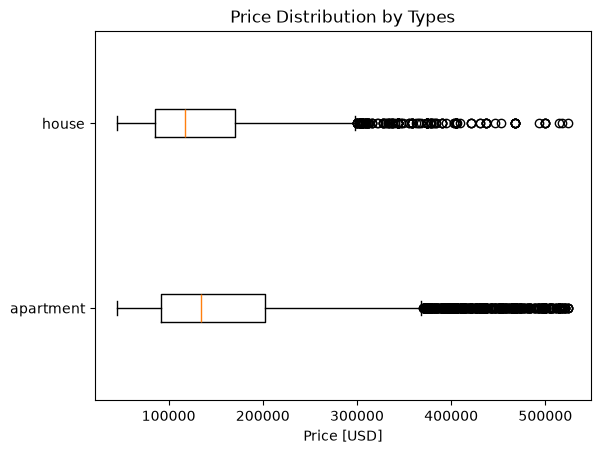

In [29]:
# -------------- Create a box plot showing distribution of property price by types ---------------

# Get the unique property types
prop_types = df["property_type"].unique()

# Create the data: produce array for each property type
data_by_type = [df[df["property_type"] == prop]["price_usd"] for prop in prop_types]


# Create the canvas and axis
fig, ax = plt.subplots()

# Define the box plot
ax.boxplot(data_by_type, orientation="horizontal", tick_labels=prop_types)

# Set the axi
ax.set_xlabel("Price [USD]")
ax.set_title("Price Distribution by Types")
# Show the box plot
plt.show()

**Observations:**
* Both type has outliers.
* House prices are more uniform.
* Apartment are sligtly more expensive.

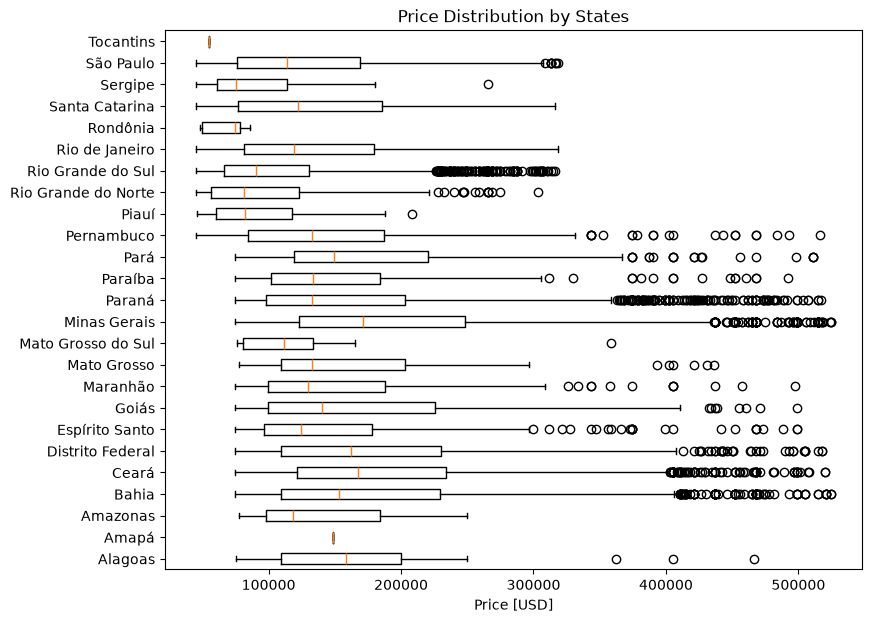

In [30]:
# ---------- Create a box plot for price distribution of property price by states ----------

# Create a list of states
states = list(df["state"].unique())

# Create data for the box plot
data_by_states = [df[df["state"] == state]["price_usd"] for state in states]

# Create the canvas and axis
fig, ax = plt.subplots(figsize=(9, 7))

# Plot the box plot
ax.boxplot(data_by_states, orientation="horizontal", tick_labels=states)

# Set the title and xlabel
ax.set_title("Price Distribution by States")
ax.set_xlabel("Price [USD]")

# Show the box plot
plt.show()

**Observations:**
* Location definitely matters for property price.
* States like Amapa, Tocanins, Rondonia and Amazons have observations to conclude anything from them.
* Outliers are everywhere.

In [31]:
df["state"].value_counts()

state
Minas Gerais           2680
São Paulo              2656
Rio Grande do Sul      2643
Rio de Janeiro         2642
Santa Catarina         2634
Paraná                 2544
Bahia                  2045
Ceará                  1574
Distrito Federal        732
Espírito Santo          555
Goiás                   555
Pernambuco              406
Rio Grande do Norte     302
Pará                    299
Paraíba                 250
Maranhão                101
Mato Grosso              86
Sergipe                  68
Alagoas                  24
Piauí                    24
Mato Grosso do Sul       14
Rondônia                  5
Amazonas                  3
Amapá                     1
Tocantins                 1
Name: count, dtype: int64

In [32]:
2656+2643+2642+318+2634+302+68+24+5+1

11293